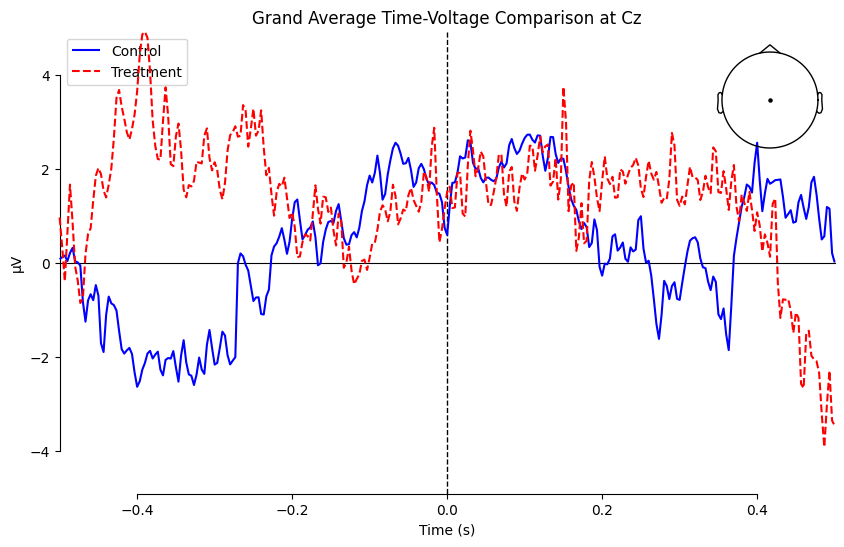

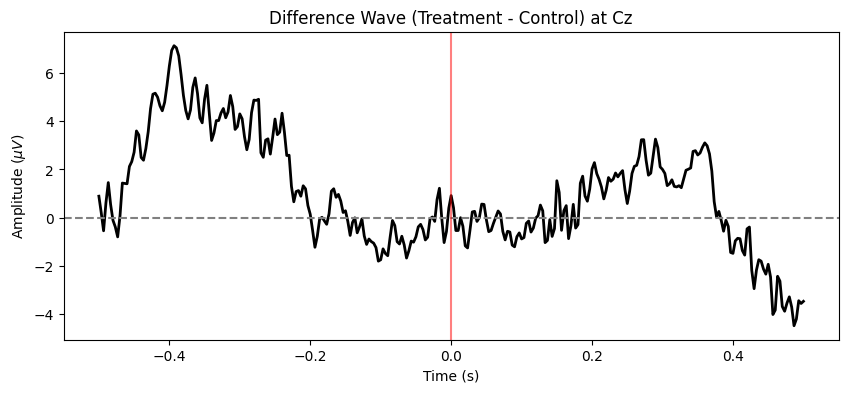

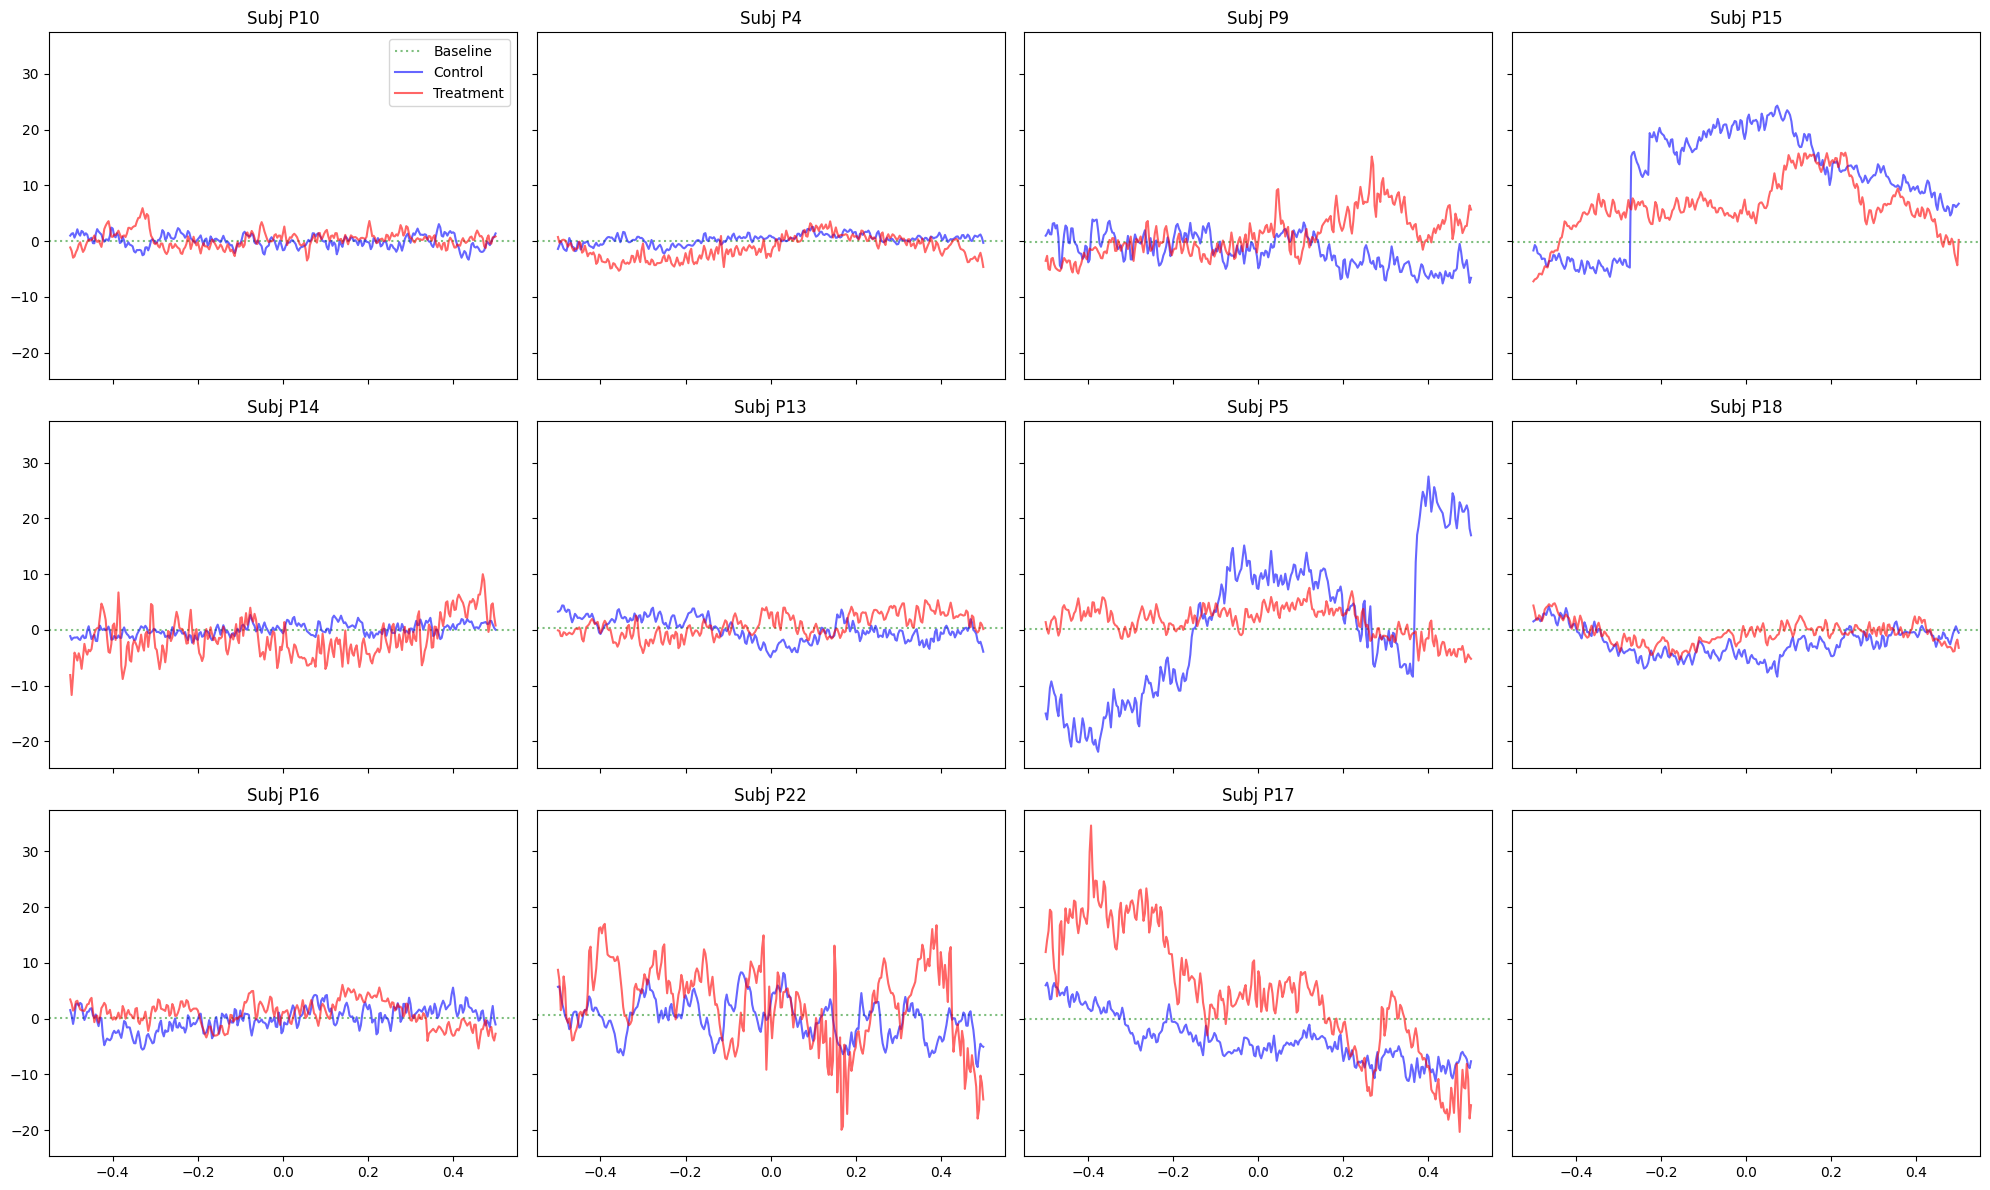

In [17]:
import mne
import os
import numpy as np
import matplotlib.pyplot as plt
mne.set_log_level('ERROR')

# --- Configuration ---

base_path = '/Users/athenasaghi/Desktop/CleanDATA/clean/'
base_path_ICA = '/Users/athenasaghi/Desktop/CleanDATA/CLEAN_BASELINES/'
chans = ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'A1', 'Fp1', 'Fp2', 'T7', 'P7', 'O1', 'O2', 'F7', 'F8', 'A2', 'P8', 'T8', 'Pz']

def get_subj(f): return f.split('_')[0]

# File Lists (truncated for brevity, use your full lists here)
control_files = [
    'P4_control_A1_postcleaning4.set', 
    'P4_control_B4_postcleaning4.set',
    'P5_control_A2_postcleaning4.set', 
    'P5_control_B3_postcleaning4.set',
    'P13_control_A2_postcleaning1.set', 
    'P13_control_B3_postcleaning1.set',
    'P9_control_A3_postcleaning1.set', 
    'P9_control_B3_postcleaning1.set',
    'P10_control_A3_postcleaning1.set', 
    'P10_control_B2_postcleaning1.set',
    'P14_control_A4_postcleaning1.set',
    'P14_control_B4_postcleaning1.set',
    'P15_control_A2_postcleaning1.set',
    'P15_control_B1_postcleaning1.set',
    'P16_control_A2_postcleaning1.set', 
    'P16_control_B3_postcleaning1.set',
    'P17_control_A2_postcleaning1.set', 
    'P17_control_A3_postcleaning1.set',
    'P18_control_A3_postcleaning1.set', 
    'P18_control_B2_postcleaning1.set',
    'P21_control_B1_postcleaning1.set', 
    'P22_control_A1_postcleaning1.set',
    'P22_control_B4_postcleaning1.set',
    'P23_control_A1_postcleaning1.set',
    'P23_control_B3_postcleaning1.set'
]

# treat_files = [
#     "P22_treatment_B3_postcleaning1.set",
#     "P4_treatment_A4_postcleaning4.set",
#     "P4_treatment_B3_postcleaning3.set",
#     "P4_treatment_B3_postcleaning4.set",
#     "P5_treatment_A1_postcleaning4.set",
#     "P5_treatment_B4_postcleaning4.set",
#     "P9_treatment_A4_postcleaning1.set",
#     "P9_treatment_B2_postcleaning1.set",
#     "P10_treatment_A2_postcleaning1.set",
#     "P10_treatment_B3_postcleaning1.set",
#     "P13_treatment_A4_postcleaning1.set",
#     "P13_treatment_B1_postcleaning1.set",
#     "P14_treatment_A2_postcleaning1.set",
#     "P15_treatment_A4_postcleaning1.set",
#     "P15_treatment_B2_postcleaning1.set",
#     "P16_treatment_A4_postcleaning1.set",
#     "P16_treatment_B2_postcleaning1.set",
#     "P17_treatment_A1_postcleaning1.set",
#     "P17_treatment_B1_postcleaning1.set",
#     "P18_treatment_A2_postcleaning1.set",
#     "P18_treatment_B3_postcleaning1.set",
# ]

common_subs = set(map(get_subj, control_files)) & set(map(get_subj, treat_files))
ctrl_filtered = [f for f in control_files if get_subj(f) in common_subs]
trtm_filtered = [f for f in treat_files if get_subj(f) in common_subs]

def process_subject_condition(file_list, sid, return_baseline=False):
    all_epochs = []
    # Load baseline
    base_f = os.path.join(base_path_ICA, f"Filter100_{sid}_baseline_.set")
    raw_b = mne.io.read_raw_eeglab(base_f, preload=True).pick(chans)
    
    # If we just want the baseline Evoked object
    if return_baseline:
        # We create a dummy Evoked object by averaging the raw baseline data
        # Note: Since baseline is continuous, we treat the whole segment as one "epoch"
        data = raw_b.get_data()
        info = raw_b.info
        return mne.EvokedArray(data.mean(axis=1, keepdims=True), info, tmin=0)

    b_mean = raw_b.get_data().mean(axis=1, keepdims=True)
    
    # Process files
    subj_files = [f for f in file_list if get_subj(f) == sid]
    for f in subj_files:
        raw = mne.io.read_raw_eeglab(os.path.join(base_path, f), preload=True).pick(chans)
        evs, ev_id = mne.events_from_annotations(raw)
        if '100' in ev_id:
            epochs = mne.Epochs(raw, evs, ev_id['100'], tmin=-0.5, tmax=0.5, baseline=None, preload=True)
            epochs._data -= b_mean 
            all_epochs.append(epochs)
    
    return mne.concatenate_epochs(all_epochs).average() if all_epochs else None

# --- Analysis ---
base_evs = [process_subject_condition([], sid, return_baseline=True) for sid in common_subs]
ctrl_evs = [process_subject_condition(ctrl_filtered, sid) for sid in common_subs]
trtm_evs = [process_subject_condition(trtm_filtered, sid) for sid in common_subs]

ga_ctrl = mne.grand_average(ctrl_evs)
ga_trtm = mne.grand_average(trtm_evs)
ga_base = mne.grand_average(base_evs)

# Create Difference Wave (Treatment - Control)
ga_diff = mne.combine_evoked([ga_trtm, ga_ctrl], weights=[1, -1])


# 1. Overlay Plot at Cz (Primary ROI)
fig, ax = plt.subplots(figsize=(10, 6))
mne.viz.plot_compare_evokeds(
    {'Control': ga_ctrl, 'Treatment': ga_trtm}, 
    picks='Cz', 
    axes=ax, 
    show=False,
    title="Grand Average Time-Voltage Comparison at Cz",
    colors={'Control': 'blue', 'Treatment': 'red'},
    linestyles={'Control': '-', 'Treatment': '--'}
)

# 2. Grand Average Difference Wave at Cz
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(ga_diff.times, ga_diff.pick('Cz').data[0] * 1e6, color='black', lw=2)
ax2.axhline(0, color='gray', linestyle='--')
ax2.axvline(0, color='red', alpha=0.5)
ax2.set_title("Difference Wave (Treatment - Control) at Cz")
ax2.set_ylabel("Amplitude ($\mu V$)")
ax2.set_xlabel("Time (s)")

# 3. Individual Participant Grid (Time-Voltage)
n_subs = len(common_subs)
fig3, axes3 = plt.subplots(int(np.ceil(n_subs/4)), 4, figsize=(20, 12), sharex=True, sharey=True)
axes3 = axes3.flatten()

for i, sid in enumerate(common_subs):
    # Plot Baseline as a horizontal line (since it's a single mean value over time)
    b_val = base_evs[i].pick('Cz').data[0][0] * 1e6
    axes3[i].axhline(y=b_val, color='green', linestyle=':', alpha=0.5, label='Baseline')
    
    axes3[i].plot(ga_ctrl.times, ctrl_evs[i].pick('Cz').data[0]*1e6, color='blue', alpha=0.6, label='Control')
    axes3[i].plot(ga_trtm.times, trtm_evs[i].pick('Cz').data[0]*1e6, color='red', alpha=0.6, label='Treatment')
    axes3[i].set_title(f"Subj {sid}")
    if i == 0: axes3[i].legend()

plt.tight_layout()
plt.show()

In [1]:
# from mne.time_frequency import tfr_morlet
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Configuration ---
# freqs = np.arange(1, 100, 0.5) 
# n_cycles = freqs / 2. 
# bands = [
#     ('Delta', 1, 4), 
#     ('Theta', 4, 8), 
#     ('Alpha', 8, 13), 
#     ('Beta', 13, 30),
#     ('Gamma', 30, 99)
# ]

# for sid in common_subs:
#     # 1. Load baseline to subtract DC offset
#     base_f = os.path.join(base_path_ICA, f"Filter100_{sid}_baseline_.set")
#     raw_b = mne.io.read_raw_eeglab(base_f, preload=True).pick(chans)
#     b_mean = raw_b.get_data().mean(axis=1, keepdims=True)

#     # 2. Process Conditions
#     for cond_name, file_list in [('Control', ctrl_filtered), ('Treatment', trtm_filtered)]:
#         subj_files = [f for f in file_list if get_subj(f) == sid]
#         if not subj_files: continue
        
#         # Load and Average Epochs
#         epochs_list = []
#         for f in subj_files:
#             raw = mne.io.read_raw_eeglab(os.path.join(base_path, f), preload=True).pick(chans)
#             evs, ev_id = mne.events_from_annotations(raw)
#             if '100' in ev_id:
#                 eps = mne.Epochs(raw, evs, ev_id['100'], tmin=-0.5, tmax=0.8, baseline=None, preload=True)
#                 eps._data -= b_mean 
#                 epochs_list.append(eps)
        
#         tfr_task = tfr_morlet(mne.concatenate_epochs(epochs_list), freqs=freqs, 
#                               n_cycles=n_cycles, return_itc=False, average=True)

#         # 3. Plotting per Band
#         for band_name, fmin, fmax in bands:
#             tfr_band = tfr_task.copy().crop(fmin=fmin, fmax=fmax)
            
#             fig, axes = plt.subplots(5, 5, figsize=(14, 10), constrained_layout=True)
#             axes = axes.flatten()
            
#             times = tfr_band.times * 1000 
#             frequencies = tfr_band.freqs

#             for i, ax in enumerate(axes):
#                 if i < len(tfr_band.ch_names):
#                     # Data shape is (n_channels, n_freqs, n_times)
#                     data = tfr_band.data[i]
                    
#                     # Apply log transformation for better visualization of power changes
#                     # This prevents the 'bright' low frequencies from hiding small changes
#                     data_plot = np.log10(data) 
                    
#                     im = ax.pcolormesh(times, frequencies, data_plot, 
#                                        shading='gouraud', cmap='RdBu_r')
                    
#                     ax.set_title(tfr_band.ch_names[i], fontweight='bold', fontsize=12)
#                     ax.axvline(0, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
                    
#                     if i >= 20: ax.set_xlabel('Time (ms)')
#                     if i % 5 == 0: ax.set_ylabel('Hz')
#                 else:
#                     ax.axis('off')

#             cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5, pad=0.02)
#             cbar.set_label('Log Power', rotation=270, labelpad=20)

#             plt.suptitle(f'Subj {sid} | {cond_name} | {band_name} ({fmin}-{fmax} Hz)', 
#                          fontsize=12, fontweight='bold')
#             plt.show()